# Preamble

In [1]:
# Running this script on a AWS Cloud SageMaker Notebook (ml.m5.2xlarge) with a volume size of 50 GB EBS

!python --version

Python 3.10.20


In [2]:
# Install Python packages that don't come pre-installed in AWS

!pip install matplotlib
!pip install pyarrow
!pip install statsmodels
!pip install scikit-learn

In [3]:
# Load required libraries

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import pyarrow
import statsmodels.api as sm
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, average_precision_score
import pickle

In [4]:
# import our user-defined functions

from data_utils import obtain_CFPB_complaints_data
from performance_metrics import evaluate_classifier

# Import Data

In [5]:
# Downloaded the CFPB compliants data from this website on June 16, 2026
# https://www.consumerfinance.gov/data-research/consumer-complaints/#get-the-data

# Data dictionary of all columns in the CFPB compliants data:
# https://cfpb.github.io/api/ccdb/fields.html

In [6]:
# Load the complaints saved locally OR obtain the complaints from our AWS S3 bucket

load_data_locally = True

if load_data_locally:
    df = pd.read_csv("complaints_in_2025_exclude_null_narratives.csv")  # just complaints data from the year 2025 (excluding null narratives)
else:
    df = obtain_CFPB_complaints_data(start_year=2025, end_year=2025, exclude_null_narratives=True, sampling=False)

In [7]:
# Switch the narrative text column to the PyArrow string backend in order to accelerate C-level string operations

df['Consumer complaint narrative'] = df['Consumer complaint narrative'].astype('string[pyarrow]')

In [8]:
# The full dataset of complaints has 15,896,496 observations
# The 2025 dataset of complaints has  5,443,005 observations
# The 2025 dataset of complaints (excluding null naratives) has 1,221,970 observations

df.shape

(1221970, 17)

In [9]:
# List the raw data types of all columns of the Pandas data frame

df.dtypes

Unnamed: 0                                int64
Date received                            object
Product                                  object
Sub-product                              object
Issue                                    object
Sub-issue                                object
Consumer complaint narrative    string[pyarrow]
Company public response                  object
Company                                  object
State                                    object
ZIP code                                 object
Tags                                     object
Submitted via                            object
Date sent to company                     object
Company response to consumer             object
Timely response?                         object
Complaint ID                              int64
dtype: object

In [10]:
# Look at a few obs

df.head()

,Unnamed: 0,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,17,2025-04-08,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,"To Whom It May Concern, I am filing a formal c...",NaN,MOHELA,NE,681XX,NaN,Web,2025-04-08,Closed with explanation,No,12856469
1,18,2025-04-15,Student loan,Federal student loan servicing,Struggling to repay your loan,"Problem with forgiveness, cancellation, or dis...",Struggling with a XXXX has significantly impac...,NaN,"Maximus Federal Services, Inc.",AL,35007,NaN,Web,2026-04-06,Closed with explanation,Yes,12989708
2,19,2025-04-18,Student loan,Federal student loan servicing,Dealing with your lender or servicer,Trouble with how payments are being handled,I have taken out parent loans on behalf of my ...,NaN,MOHELA,OH,43110,Servicemember,Web,2025-04-18,Closed with explanation,No,13062648
3,22,2025-05-21,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,On my XXXX credit report it has my student lo...,NaN,MOHELA,CO,80020,NaN,Web,2025-05-21,Closed with explanation,No,13618226
4,23,2025-05-29,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,I XXXX XXXX am writing to tell you about whats...,NaN,MOHELA,MI,48228,Servicemember,Web,2025-05-29,Closed with explanation,No,13768659


# Explore Data

In [11]:
# Group complaints by product category and count observations

df.groupby(df['Product']).size()

Product
Checking or savings account                                 51447
Credit card                                                 41494
Credit reporting or other personal consumer reports        912758
Debt collection                                            100600
Debt or credit management                                    2641
Money transfer, virtual currency, or money service          64832
Mortgage                                                    14015
Payday loan, title loan, personal loan, or advance loan      7800
Prepaid card                                                 3822
Student loan                                                10881
Vehicle loan or lease                                       11680
dtype: int64

In [12]:
# Convert the Product categorical variable into a collectino of dummy variables
# use the category 'Credit reporting or other personal consumer reports' as the baseline category (because it is the most common)

df['Product'] = pd.Categorical(df['Product'], categories=['Credit reporting or other personal consumer reports',
                                                          'Checking or savings account', 
                                                          'Credit card', 
                                                          'Debt collection', 
                                                          'Debt or credit management', 
                                                          'Money transfer, virtual currency, or money service', 
                                                          'Mortgage', 
                                                          'Payday loan, title loan, personal loan, or advance loan', 
                                                          'Prepaid card', 
                                                          'Student loan', 
                                                          'Vehicle loan or lease'])

df = pd.get_dummies(df, columns=['Product'], drop_first=True, dtype=int)

In [13]:
# Group by the tags and count obsevations

df.groupby(df['Tags']).size()

Tags
Older American                   16263
Older American, Servicemember     4815
Servicemember                    51704
dtype: int64

In [14]:
# Recode this categorical feature of 'Tags' into two separate binary features

df['Older American'] = np.where(df['Tags'].isin(['Older American','Older American, Servicemember']), 1, 0)
df['Servicemember'] = np.where(df['Tags'].isin(['Servicemember','Older American, Servicemember']), 1, 0)

In [15]:
# Group by company response to consumer and count obsevations

df.groupby(df['Company response to consumer']).size()

Company response to consumer
Closed with explanation            768024
Closed with monetary relief         15145
Closed with non-monetary relief    434484
In progress                           116
Untimely response                    4201
dtype: int64

In [16]:
# Collapse company response to consumer into a binary target: 

#   1 = complaint closed respectfully (with an explanation OR a monetary relief)
#   0 = complaint closed with no explanation nor monetary relief

df['Target of Complaint Closed Respectfully'] = np.where(df['Company response to consumer'].isin(['Closed with explanation','Closed with monetary relief']), 1, 0)

In [17]:
# Group by target and count obsevations

df.groupby(df['Target of Complaint Closed Respectfully']).size()

Target of Complaint Closed Respectfully
0    438801
1    783169
dtype: int64

In [18]:
# Count up the number of unique companies of consumer complaints

df['Company'].nunique()

3224

In [19]:
# Find the top 20 companies with the most consumer complaints

df['Company'].value_counts().head(20)

Company
EQUIFAX, INC.                             315504
TRANSUNION INTERMEDIATE HOLDINGS, INC.    294058
Experian Information Solutions Inc.       268568
Block, Inc.                                38103
Early Warning Services, LLC                17665
CAPITAL ONE FINANCIAL CORPORATION          17160
JPMORGAN CHASE & CO.                       11795
NAVY FEDERAL CREDIT UNION                  10624
CITIBANK, N.A.                              9160
WELLS FARGO & COMPANY                       9047
BANK OF AMERICA, NATIONAL ASSOCIATION       8874
Resurgent Capital Services L.P.             8004
SYNCHRONY FINANCIAL                         6277
ENCORE CAPITAL GROUP INC.                   5684
Chime Financial Inc                         5648
MOHELA                                      5285
CL Holdings LLC                             5185
Portfolio Recovery Associates, LLC          5115
Paypal Holdings, Inc                        4809
AMERICAN EXPRESS COMPANY                    4766
Name: count,

In [20]:
# Print consumer complaints where the complaint narrative contains a specific keyword

keyword = 'Data Science'

with pd.option_context('display.max_colwidth', None):
    filtered_column = df.loc[df['Consumer complaint narrative'].str.contains(keyword, case=False, na=False), 'Consumer complaint narrative']
    print(filtered_column)

420603    I enrolled in a one-year Postgraduate in Data Science program with XXXX XXXX XXXX XXXX from XX/XX/XXXX to XX/XX/XXXX. Toward the end of the program, I received a phone call from a XXXX XXXX representative named XXXX, who offered me an upgrade to a XXXX XXXX from XXXX de XXXX, stating it was free to explore and that there would be no financial obligation unless I chose to proceed. \n\nXXXX sent me a link to a site called Kodakco.com, assuring me it was just to check the upgrade offer or try it temporarily. Trusting XXXX XXXX as an educational provider, I clicked the link and followed instructions but I was misled into believing this was a no-obligation trial, not a financial agreement. I now realize I XXXX have unintentionally agreed to a {$1000.00} Klarna financing under false pretenses. \n\nSoon after, I was notified by Klarna of a {$1000.00} debt in my name linked to XXXX. There was no transparent checkout process or consent to financing terms. I took immediate action conta

# Feature Engineering

In [21]:
# Print out the current columns in the data frame

print(df.columns.tolist())

['Unnamed: 0', 'Date received', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Complaint ID', 'Product_Checking or savings account', 'Product_Credit card', 'Product_Debt collection', 'Product_Debt or credit management', 'Product_Money transfer, virtual currency, or money service', 'Product_Mortgage', 'Product_Payday loan, title loan, personal loan, or advance loan', 'Product_Prepaid card', 'Product_Student loan', 'Product_Vehicle loan or lease', 'Older American', 'Servicemember', 'Target of Complaint Closed Respectfully']


In [22]:
# Count up the words in the consumer complaint narrative

df['complaint_word_count'] = df['Consumer complaint narrative'].str.split().str.len()

In [23]:
# Binary flag if the $ dollar sign in the consumer complaint narrative

df['dollar_sign'] = df['Consumer complaint narrative'].str.contains('$', na=False).astype(int)

In [24]:
# Binary flag if there are keywords related to critical severity in the consumer complaint narrative

critical_severity_keywords = ['foreclosure', 'eviction', 'bankruptcy', 'homeless', 'sheriff sale', 'lease termination', 'padlock', 'shelter', 'garnishment', 'attorney general', 'summons', 'court order', 'judgment', 'wage attachment', 'poverty', 'destitute', 'hardship', 'suicidal']
critical_severity_pattern = '|'.join(critical_severity_keywords)

df['critical_severity_keywords'] = df['Consumer complaint narrative'].str.contains(critical_severity_pattern, case=False, na=False).astype(int)

In [25]:
# Binary flag if there are keywords related to high severity in the consumer complaint narrative

high_severity_keywords = ['fraud', 'scam', 'unauthorized transaction', 'account takeover', 'phishing', 'impersonation', 'forgery', 'closed account', 'repossession', 'collections', 'frozen account', 'account lock', 'charge off', 'predatory lending', 'harassment']
high_severity_pattern = '|'.join(high_severity_keywords)

df['high_severity_keywords'] = df['Consumer complaint narrative'].str.contains(high_severity_pattern, case=False, na=False).astype(int)

In [26]:
# Binary flag if there are keywords related to medium severity in the consumer complaint narrative

medium_severity_keywords = ['credit score', 'dispute', 'fcra', 'late fee', 'hidden charge', 'interest rate increase', 'billing error', 'escrow shortage']
medium_severity_pattern = '|'.join(medium_severity_keywords)

df['medium_severity_keywords'] = df['Consumer complaint narrative'].str.contains(medium_severity_pattern, case=False, na=False).astype(int)

In [27]:
# Binary flag if there are keywords related to legal risk in the consumer complaint narrative

legal_risk_keywords = ['lawsuit', 'attorney', 'lawyer', 'court', 'subpoena', 'legal action', 'suing', 'fcra violation', 'fdcpa', 'tcpa', 'regulatory complaint']
legal_risk_pattern = '|'.join(legal_risk_keywords)

df['legal_risk_keywords'] = df['Consumer complaint narrative'].str.contains(legal_risk_pattern, case=False, na=False).astype(int)

In [28]:
# Binary flag if there are keywords related to financial loss in the consumer complaint narrative

financial_loss_keywords = ['stolen funds', 'overdraft fee', 'unauthorized charge', 'drained account', 'wire fraud', 'double charged', 'seized funds', 'unauthorized fee']
financial_loss_pattern = '|'.join(financial_loss_keywords)

df['financial_loss_keywords'] = df['Consumer complaint narrative'].str.contains(financial_loss_pattern, case=False, na=False).astype(int)

In [29]:
# Binary flag if there are keywords related to credit damage in the consumer complaint narrative

credit_damage_keywords = ['credit score dropped', 'incorrect reporting', 'derogatory mark', 'late payment reported', 'identity theft', 'mixed file', 'unverified debt']
credit_damage_pattern = '|'.join(credit_damage_keywords)

df['credit_damage_keywords'] = df['Consumer complaint narrative'].str.contains(credit_damage_pattern, case=False, na=False).astype(int)

In [30]:
# Binary flag if the company is a credit bureau 

df['credit_bureau'] = np.where(df['Company'].isin(['EQUIFAX, INC.',
                                                   'TRANSUNION INTERMEDIATE HOLDINGS, INC.', 
                                                   'Experian Information Solutions Inc.']), 1, 0)

In [31]:
# Binary flag if the company is a credit union

df['credit_union'] = df['Company'].str.contains('credit union', case=False, na=False).astype(int)

In [32]:
# Binary flag if the complaint comes from a Southern state (defined as Region 3 by the US Census)
# https://www2.census.gov/programs-surveys/popest/datasets/2020-2025/state/totals/NST-EST2025-ALLDATA.csv

Southern_States = ['AL', 'AR', 'DE', 'FL', 'GA', 'KY', 'LA', 'MD', 'MS', 'NC', 'OK', 'SC', 'TN', 'TX', 'VA', 'WV']

df['Southern_State'] = df['State'].isin(Southern_States).astype(int)

In [33]:
# Convert NaN to 0

df = df.fillna(0)

In [34]:
# Confirm that the shape of the data frame has not been affected

df.shape

(1221970, 40)

# Prepare for Modeling

In [35]:
# Print out the current columns in the data frame

print(df.columns.tolist())

['Unnamed: 0', 'Date received', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Complaint ID', 'Product_Checking or savings account', 'Product_Credit card', 'Product_Debt collection', 'Product_Debt or credit management', 'Product_Money transfer, virtual currency, or money service', 'Product_Mortgage', 'Product_Payday loan, title loan, personal loan, or advance loan', 'Product_Prepaid card', 'Product_Student loan', 'Product_Vehicle loan or lease', 'Older American', 'Servicemember', 'Target of Complaint Closed Respectfully', 'complaint_word_count', 'dollar_sign', 'critical_severity_keywords', 'high_severity_keywords', 'medium_severity_keywords', 'legal_risk_keywords', 'financial_loss_keywords', 'credit_damage_keywords', 'credit_bureau', 'credit_union', 'Southern_State']


In [36]:
# Subset just the relevant columns in the data frame

relevant_columns = ['Target of Complaint Closed Respectfully',
                    'Product_Checking or savings account',
                    'Product_Credit card',
                    'Product_Debt collection',
                    'Product_Debt or credit management',
                    'Product_Money transfer, virtual currency, or money service',
                    'Product_Mortgage',
                    'Product_Payday loan, title loan, personal loan, or advance loan',
                    'Product_Prepaid card',
                    'Product_Student loan',
                    'Product_Vehicle loan or lease',
                    'Older American',
                    'Servicemember',
                    'complaint_word_count',
                    'dollar_sign',
                    'critical_severity_keywords',
                    'high_severity_keywords',
                    'medium_severity_keywords',
                    'financial_loss_keywords',
                    'credit_damage_keywords',
                    'credit_bureau',
                    'credit_union',
                    'Southern_State']

subset_df = df[relevant_columns]

In [37]:
# Clean up the column names for consistency by replacing commas and blank spaces with underscores

subset_df.columns = subset_df.columns.str.replace(",", "")
subset_df.columns = subset_df.columns.str.replace(" ", "_")

print(subset_df.columns.tolist())

['Target_of_Complaint_Closed_Respectfully', 'Product_Checking_or_savings_account', 'Product_Credit_card', 'Product_Debt_collection', 'Product_Debt_or_credit_management', 'Product_Money_transfer_virtual_currency_or_money_service', 'Product_Mortgage', 'Product_Payday_loan_title_loan_personal_loan_or_advance_loan', 'Product_Prepaid_card', 'Product_Student_loan', 'Product_Vehicle_loan_or_lease', 'Older_American', 'Servicemember', 'complaint_word_count', 'dollar_sign', 'critical_severity_keywords', 'high_severity_keywords', 'medium_severity_keywords', 'financial_loss_keywords', 'credit_damage_keywords', 'credit_bureau', 'credit_union', 'Southern_State']


In [38]:
# Look at the data subset

subset_df.head()

,Target_of_Complaint_Closed_Respectfully,Product_Checking_or_savings_account,Product_Credit_card,Product_Debt_collection,Product_Debt_or_credit_management,Product_Money_transfer_virtual_currency_or_money_service,Product_Mortgage,Product_Payday_loan_title_loan_personal_loan_or_advance_loan,Product_Prepaid_card,Product_Student_loan,...,complaint_word_count,dollar_sign,critical_severity_keywords,high_severity_keywords,medium_severity_keywords,financial_loss_keywords,credit_damage_keywords,credit_bureau,credit_union,Southern_State
0,1,0,0,0,0,0,0,0,0,0,...,173,1,0,0,1,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,1,...,98,1,0,0,0,0,0,0,0,1
2,1,0,0,0,0,0,0,0,0,1,...,292,1,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,26,1,0,0,1,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,356,1,0,0,1,0,1,0,0,0


In [39]:
# Separate feature vector (X) and target variable (y)

X = subset_df.drop('Target_of_Complaint_Closed_Respectfully', axis=1)
y = subset_df['Target_of_Complaint_Closed_Respectfully']

In [40]:
# Split the data into a training partition and a hold-out validation partition (70% training, 30% holdout)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Logistic Regression Model using Statsmodels

In [41]:
# Add a column of 1s to the feature set because statsmodels does not automatically add an intercept

X_train_with_constant = sm.add_constant(X_train)

In [42]:
# Fit a logistic regression model using statsmodel on the training data with robust standard errors
# https://blog.stata.com/2022/10/06/heteroskedasticity-robust-standard-errors-some-practical-considerations/

logistic_reg_stats_models = sm.Logit(y_train, X_train_with_constant).fit(cov_type='HC1')

Optimization terminated successfully.
         Current function value: 0.583931
         Iterations 8


In [43]:
# 2. View statistical summary of the results of fitting a Logistic regression model

print(logistic_reg_stats_models.summary())

                                      Logit Regression Results                                     
Dep. Variable:     Target_of_Complaint_Closed_Respectfully   No. Observations:               855379
Model:                                               Logit   Df Residuals:                   855357
Method:                                                MLE   Df Model:                           21
Date:                                     Sat, 01 Aug 2026   Pseudo R-squ.:                  0.1055
Time:                                             03:14:44   Log-Likelihood:            -4.9948e+05
converged:                                            True   LL-Null:                   -5.5839e+05
Covariance Type:                                       HC1   LLR p-value:                     0.000
                                                                   coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------

In [44]:
# Convert the Logistic regression model coefficients into Odds Ratios

# Extract log-odds coefficients and confidence intervals
df_coefficients = logistic_reg_stats_models.params.to_frame(name='Log-Odds')
df_confidence_intervals = logistic_reg_stats_models.conf_int()

# Combine them into a single summary DataFrame
odds_summary = pd.concat([df_coefficients, df_confidence_intervals], axis=1)
odds_summary.columns = ['Log-Odds', 'Lower CI (Log)', 'Upper CI (Log)']

# Exponentiate the entire DataFrame to calculate Odds Ratios
odds_summary['Odds Ratio'] = np.exp(odds_summary['Log-Odds'])
odds_summary['OR Lower CI'] = np.exp(odds_summary['Lower CI (Log)'])
odds_summary['OR Upper CI'] = np.exp(odds_summary['Upper CI (Log)'])

# Display the finalized odds ratios
odds_summary[['Odds Ratio', 'OR Lower CI', 'OR Upper CI']]

,Odds Ratio,OR Lower CI,OR Upper CI
Product_Checking_or_savings_account,4.860208,4.598196,5.137149
Product_Credit_card,1.819773,1.752289,1.889855
Product_Debt_collection,1.042265,1.020059,1.064954
Product_Debt_or_credit_management,2.483282,2.145865,2.873755
Product_Money_transfer_virtual_currency_or_money_service,16.401459,15.126231,17.784196
Product_Mortgage,7.907559,7.037879,8.884705
Product_Payday_loan_title_loan_personal_loan_or_advance_loan,5.271852,4.635482,5.995585
Product_Prepaid_card,4.710505,3.964658,5.596664
Product_Student_loan,1.150666,1.082529,1.223091
Product_Vehicle_loan_or_lease,3.790955,3.462568,4.150486


# Logistic Regression Model using Scikit-learn

In [45]:
# Scale features (recommended for faster solver convergence) using just the Training partition to prevent data leakage

scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
# Initialize and fit the Logistic Regression model

logistic_reg_sklearn_model = LogisticRegression(class_weight='balanced', solver='lbfgs', max_iter=100)
logistic_reg_sklearn_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [47]:
# Make predictions on the holdout validation partition using the Logistic Regression model

logistic_reg_y_pred  = logistic_reg_sklearn_model.predict(X_test_scaled)              # Predict binary class (0 or 1)
logistic_reg_y_probs = logistic_reg_sklearn_model.predict_proba(X_test_scaled)[:, 1]  # Predict raw probabilities

Accuracy Score: 0.58

Average Precision Score (summarizes the Precision-Recall curve): 0.81

Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.91      0.61    131781
           1       0.88      0.39      0.55    234810

    accuracy                           0.58    366591
   macro avg       0.67      0.65      0.58    366591
weighted avg       0.73      0.58      0.57    366591

Confusion Matrix:


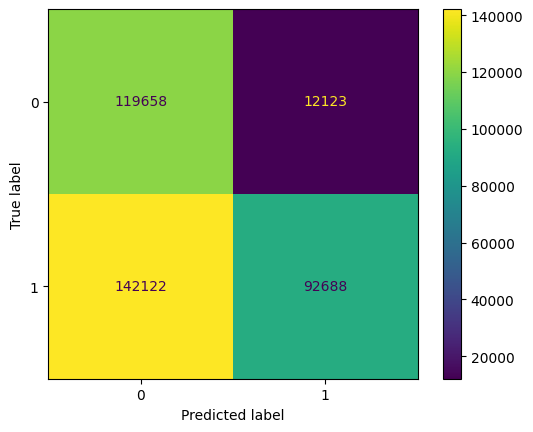

In [48]:
# Calculate performance metrics on the holdout data to evaluate the Logistic Regression model

evaluate_classifier(logistic_reg_sklearn_model, y_test, logistic_reg_y_pred, logistic_reg_y_probs)

In [49]:
# Save the model to disk as a pickle file

with open("logistic_reg_sklearn_model.pkl", "wb") as file:
    pickle.dump(logistic_reg_sklearn_model, file)

# Gradient Boosting Model using Scikit-learn

In [50]:
# Initialize and train the Gradient Boosting model on just the training partition

grad_boost_sklearn_model = HistGradientBoostingClassifier(class_weight='balanced', max_iter=100, learning_rate=0.1, max_depth=5, random_state=42)
grad_boost_sklearn_model.fit(X_train.values, y_train)

,loss,'log_loss'
,learning_rate,0.1
,max_iter,100
,max_leaf_nodes,31
,max_depth,5
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


In [51]:
# Make predictions on the holdout validation partition using the Gradient Boosting model

grad_boost_y_pred = grad_boost_sklearn_model.predict(X_test.values)               # Predict binary class (0 or 1)
grad_boost_y_probs = grad_boost_sklearn_model.predict_proba(X_test.values)[:, 1]  # Predict raw probabilities

Accuracy Score: 0.58

Average Precision Score (summarizes the Precision-Recall curve): 0.82

Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.90      0.61    131781
           1       0.88      0.40      0.55    234810

    accuracy                           0.58    366591
   macro avg       0.67      0.65      0.58    366591
weighted avg       0.73      0.58      0.57    366591

Confusion Matrix:


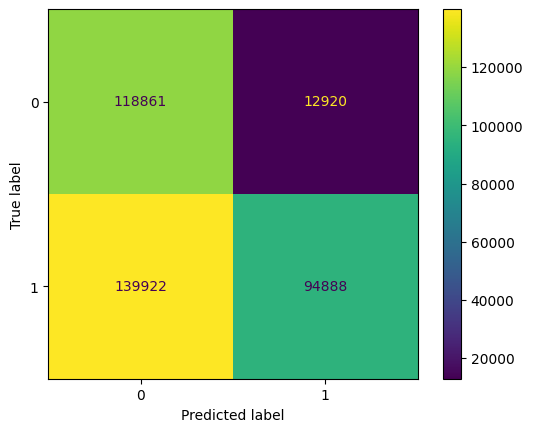

In [52]:
# Calculate performance metrics on the holdout data to evaluate the Gradient Boosting model

evaluate_classifier(grad_boost_sklearn_model, y_test, grad_boost_y_pred, grad_boost_y_probs)

In [53]:
# Save the model to disk as a pickle file

with open("grad_boost_sklearn_model.pkl", "wb") as file:
    pickle.dump(grad_boost_sklearn_model, file)

# Random Forest Model using Scikit-learn

In [54]:
# Initialize and train the Random Forest model on just the training partition

random_forest_sklearn_model = RandomForestClassifier(class_weight='balanced', n_estimators=100, max_depth=5, random_state=42)
random_forest_sklearn_model.fit(X_train.values, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [55]:
# Make predictions on the holdout validation partition using the Random Forest model

random_forest_y_pred = random_forest_sklearn_model.predict(X_test.values)               # Predict binary class (0 or 1)
random_forest_y_probs = random_forest_sklearn_model.predict_proba(X_test.values)[:, 1]  # Predict raw probabilities

Accuracy Score: 0.58

Average Precision Score (summarizes the Precision-Recall curve): 0.82

Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.91      0.61    131781
           1       0.89      0.39      0.54    234810

    accuracy                           0.58    366591
   macro avg       0.67      0.65      0.58    366591
weighted avg       0.73      0.58      0.57    366591

Confusion Matrix:


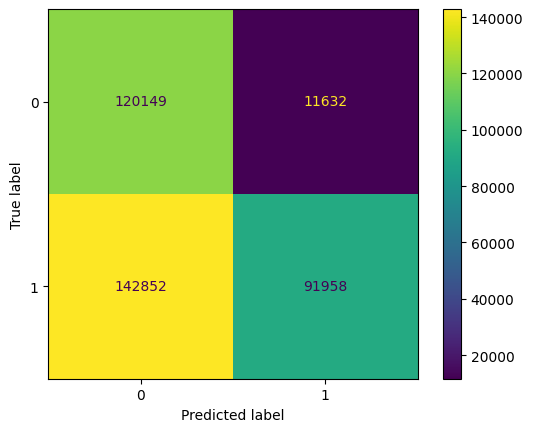

In [56]:
# Calculate performance metrics on the holdout data to evaluate the Gradient Boosting model

evaluate_classifier(random_forest_sklearn_model, y_test, random_forest_y_pred, random_forest_y_probs)

In [57]:
# Save the model to disk as a pickle file

with open("random_forest_sklearn_model.pkl", "wb") as file:
    pickle.dump(random_forest_sklearn_model, file)

# Notes for Implementing Scoring

In [58]:
# https://docs.streamlit.io/get-started/installation

# https://docs.streamlit.io/get-started/installation/community-cloud

# https://share.streamlit.io/

# https://docs.streamlit.io/get-started/installation